In [1]:
import numpy as np
import matplotlib.pyplot as plt


Ok, now we are going to make a little toy that demonstrates the bias in the selection. What we are going to do is find the counts within a radius of a sample, thats going to be `densest_point`. Then what we are going to do is compute all the points with a cone of a central coordinate and return those poitns thats `local_density`


In [2]:
def findDist(iPoints, iRef, iNTop):
    lDist = np.linalg.norm(iPoints - iRef, axis=1)
    top_indices = np.argpartition(distances, iNTop)[:iNTop]
    return np.maximum[distances[top_indices]]

def findCenter(iPoints,iPercent=0.1):
    n_top = max(1, int(iPercent * len(iPoints)))  # Ensure at least 1 point
    dist = []
    for pPoint in iPoints:
        pDist = findDist(iPoints, pPoint, n_top)
        dist.append(pDist)
    dist = np.asarray(dist)
    min_dist = np.argmin(dist)
    return iPtoins[min_dist] 
    
    
def densest_point(points, radius):
    points = np.asarray(points)
    N = len(points)

    # Compute pairwise distances
    diff = points[:,:, np.newaxis, :] - points[:,np.newaxis, :, :]  # shape (N, N, D)
    dists = np.linalg.norm(diff, axis=3)  # shape (N, N)
    # Count neighbors within radius (exclude self by setting diagonal to inf)
    for pVal in range(dists.shape[0]):
        np.fill_diagonal(dists[pVal], np.inf)
    
    neighbor_counts = np.sum(dists < radius, axis=2)
    densest_idx = np.argmax(neighbor_counts,axis=1)
    return points[:,densest_idx],neighbor_counts, densest_idx

def local_density(iPoints,iCenters,radius=0.1):
    dists = np.linalg.norm(iPoints - iCenters[:,np.newaxis,:], axis=2)
    points = dists < radius
    neighbor_counts = np.sum(points, axis=1)
    outpoints = []
    for i0,pPoints in enumerate(iPoints):
        outpoints.append(pPoints[points[i0]])
    #outpoints = np.asarray(outpoints)
    return neighbor_counts, outpoints


Now, lets sample uniform from 2 dimensions 500 toys with 500 sampled points. For each, what we will do is compute the number of points within a radius of 0.1 and we will plot the density for the chosen point, and for a random point.

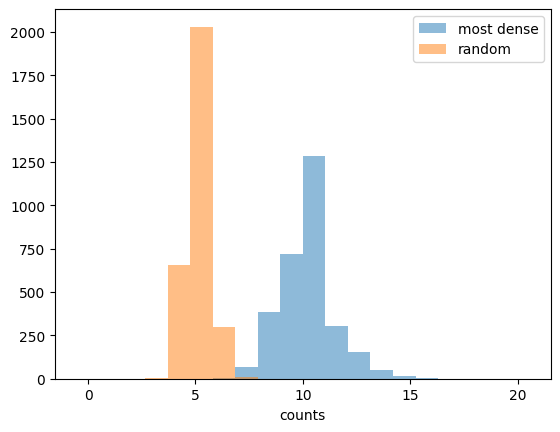

In [49]:
nexp=3000
ntot=50
points = np.random.rand(nexp,ntot, 2)
centers, counts, idx = densest_point(points, radius=0.2)
#counts_tot = np.sum(counts[:,idx]*np.eye(idx.shape[0]),axis=1)
counts_top  = np.sum(counts[:,idx]*np.eye(idx.shape[0]),axis=1)
counts_mean = np.mean(counts,axis=1)
bins=np.linspace(-0.5,20.5,21)
plt.hist(counts_top,alpha=0.5,bins=bins,label='most dense')
plt.hist(counts_mean,alpha=0.5,bins=bins,label='random')
plt.xlabel('counts')
plt.legend()
plt.show()


Now that we have doneo that, lets setup a k-fold. What we will do is merge 2 sampled toys into 1 by finding the max in each toy, then using that max for the next toy and visa-versa, then taking all of these points and computing the RMS of the merged points. If the selection is biased, as we would expect the RMS of the poitns should be smaller for two randomly chosen points. 

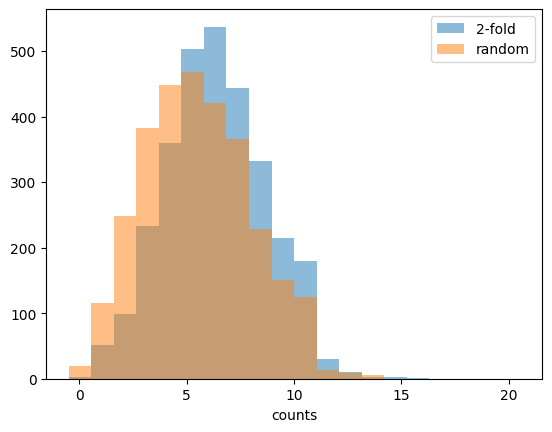

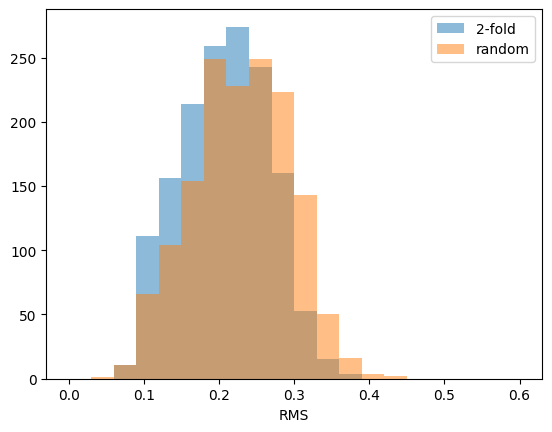

0.2078003003063438 0.2298283265514431


In [50]:
#now lets plot the k-fold density for 2-fold
centers=[]
randoms=[]
for i0,pPoints in enumerate(points):
    centers.append(pPoints[idx[i0]])
    pRand=np.random.randint(0,ntot)
    randoms.append(pPoints[pRand])
centers=np.asarray(centers)
randoms=np.asarray(randoms)
bcounts,biased_points    = local_density(points,centers,radius=0.1)
t0counts,TwoFold0_points = local_density(points[0::2],centers[1::2],radius=0.2)
t1counts,TwoFold1_points = local_density(points[1::2],centers[0::2],radius=0.2)
t2counts,TwoFold2_points = local_density(points[0::2],randoms[1::2],radius=0.2)
t3counts,TwoFold3_points = local_density(points[1::2],randoms[0::2],radius=0.2)

#TwoFold0_points.extend(TwoFold1_points)
TwoFold_rms = []
for i0 in range(len(TwoFold0_points)):
    pPoint0 = TwoFold0_points[i0]
    pPoint1 = TwoFold1_points[i0]
    pPoints = np.append(pPoint0,pPoint1)
    TwoFold_rms.append(pPoints.std())

TwoFold3_rms = []
#TwoFold2_points.extend(TwoFold3_points)
for i0 in range(len(TwoFold2_points)):
    pPoint0 = TwoFold2_points[i0]
    pPoint1 = TwoFold3_points[i0]
    pPoints = np.append(pPoint0,pPoint1)
    TwoFold3_rms.append(pPoints.std())

bins=np.linspace(-0.5,20.5,21)
#plt.hist(bcounts,bins=bins,alpha=0.5)
tcounts  = np.append(t0counts,t1counts)
t3counts = np.append(t2counts,t3counts)
plt.hist(tcounts,bins=bins,alpha=0.5,label="2-fold")
plt.hist(t3counts,bins=bins,alpha=0.5,label="random")
plt.xlabel('counts')
plt.legend()
plt.show()

bins=np.linspace(0,0.6,21)
plt.hist(TwoFold_rms,bins=bins,alpha=0.5,label="2-fold")
plt.hist(TwoFold3_rms,bins=bins,alpha=0.5,label="random")
plt.xlabel('RMS')
plt.legend()
plt.show()
dogs0=np.asarray(TwoFold_rms)
dogs1=np.asarray(TwoFold3_rms)
print(dogs0[dogs0 > 0].mean(),dogs1[dogs1 > 0].mean())
#print("RMS:",(np.asarray(TwoFold_rms) > -1).mean(),(np.asarray(TwoFold3_rms) > -1).mean())


Now, lets do it for k-fold=5. We will see this enhancs the bias significantly by isolating a much smaller region.

A: 1
A: 2
A: 3
A: 4
A: 5


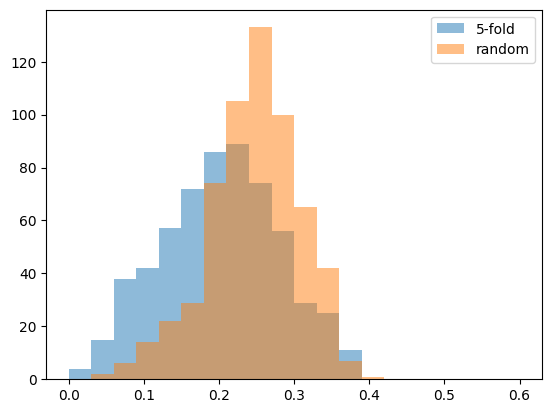

In [51]:
#now lets plot the k-fold density for n-fold
n=5
def kfold(iN,iPoints,radius=0.1):
    Fold_pointsB = []
    Fold_pointsR = []
    for pVal in range(iN):
        pPoints_k = points[pVal::iN]
        pId = 0
        if pVal == 0:
            pId = 1
        pPoints_tot = points[pId::iN]
        for pVal1 in np.arange(pId+1,iN):
            if pVal1 == pVal:
                continue
            pPoints_tot = np.append(pPoints_tot,points[pVal1::iN],axis=1)
        centers, counts, idx  = densest_point(pPoints_tot, radius=radius)
        centers=[]
        randoms=[]
        ntot=pPoints_tot.shape[1]
        for i0,pPoints in enumerate(pPoints_tot):
            centers.append(pPoints[idx[i0]])
            pRand=np.random.randint(0,ntot)
            randoms.append(pPoints[pRand])
        centers=np.asarray(centers)
        randoms=np.asarray(randoms)
        tBcounts,Fold_pointsKB = local_density(pPoints_k,centers,radius=radius)            
        tRcounts,Fold_pointsKR = local_density(pPoints_k,randoms,radius=radius)
        Fold_pointsB.append(Fold_pointsKB)
        Fold_pointsR.append(Fold_pointsKR)
        print("A:",len(Fold_pointsB))
    Fold_rmsB = []
    Fold_rmsR = []
    for i0 in range(len(Fold_pointsB[0])):
        pPoint0 = Fold_pointsB[0][i0]
        for i1 in np.arange(1,iN):
            pPoint1 = Fold_pointsB[i1][i0]
            pPoint0 = np.append(pPoint0,pPoint1)
        Fold_rmsB.append(pPoint0.std())

    for i0 in range(len(Fold_pointsR[0])):
        pPoint0 = Fold_pointsR[0][i0]
        for i1 in np.arange(1,iN):
            pPoint1 = Fold_pointsR[i1][i0]
            pPoint0 = np.append(pPoint0,pPoint1)
        Fold_rmsR.append(pPoint0.std())
    return Fold_rmsB,Fold_rmsR

#tmp0=points[0::5]
#tmp1=points[0::5]
#print(tmp0.shape)
#tmp = np.append(tmp0,tmp1,axis=1)
#print(tmp.shape)
#print(np.arange(1,10))
rms,rand_rms=kfold(n,points)
bins=np.linspace(0,0.6,21)
plt.hist(rms,bins=bins,alpha=0.5,label="5-fold")
plt.hist(rand_rms,bins=bins,alpha=0.5,label="random")
plt.legend()
plt.show()


Lets try some others, the trend beomes super clear as we go to large k.

A: 1
A: 2


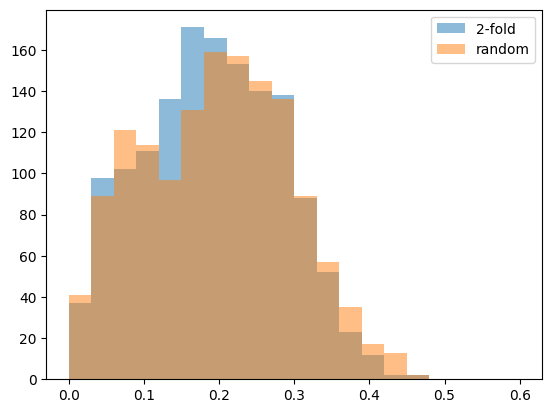

A: 1
A: 2
A: 3


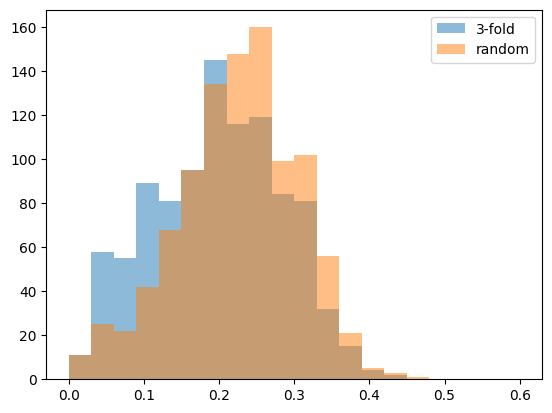

A: 1
A: 2
A: 3
A: 4


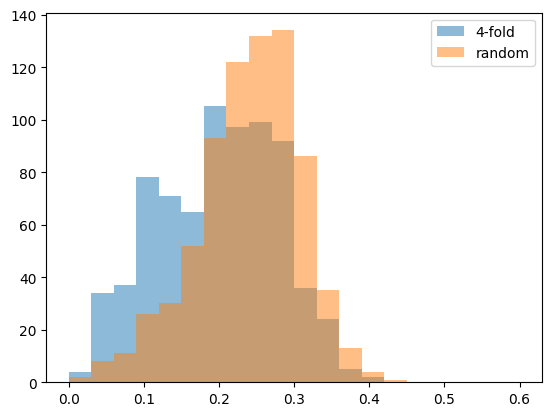

A: 1
A: 2
A: 3
A: 4
A: 5


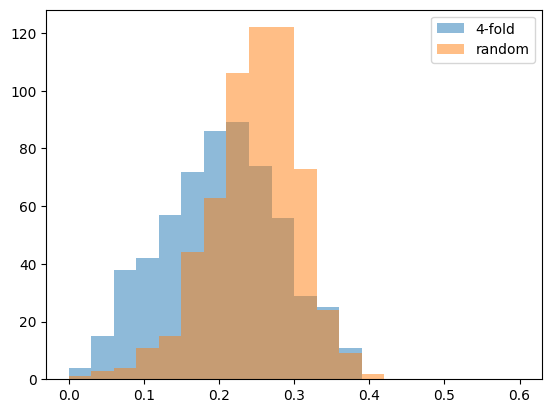

A: 1
A: 2
A: 3
A: 4
A: 5
A: 6


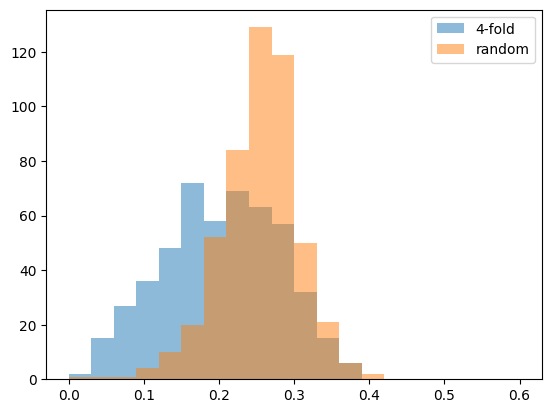

A: 1
A: 2
A: 3
A: 4
A: 5
A: 6
A: 7
A: 8


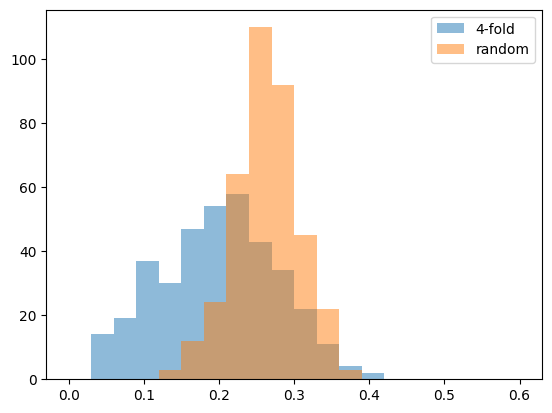

A: 1
A: 2
A: 3
A: 4
A: 5
A: 6
A: 7
A: 8
A: 9
A: 10


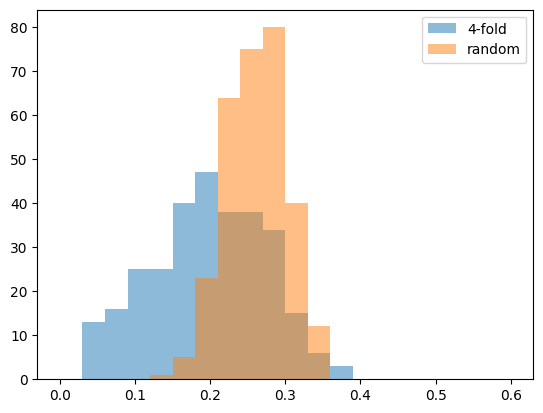

In [53]:
n=2
rms,rand_rms=kfold(n,points)
bins=np.linspace(0,0.6,21)
plt.hist(rms,bins=bins,alpha=0.5,label="2-fold")
plt.hist(rand_rms,bins=bins,alpha=0.5,label="random")
plt.legend()
plt.show()

n=3
rms,rand_rms=kfold(n,points)
bins=np.linspace(0,0.6,21)
plt.hist(rms,bins=bins,alpha=0.5,label="3-fold")
plt.hist(rand_rms,bins=bins,alpha=0.5,label="random")
plt.legend()
plt.show()


n=4
rms,rand_rms=kfold(n,points)
bins=np.linspace(0,0.6,21)
plt.hist(rms,bins=bins,alpha=0.5,label="4-fold")
plt.hist(rand_rms,bins=bins,alpha=0.5,label="random")
plt.legend()
plt.show()

n=5
rms,rand_rms=kfold(n,points)
bins=np.linspace(0,0.6,21)
plt.hist(rms,bins=bins,alpha=0.5,label="4-fold")
plt.hist(rand_rms,bins=bins,alpha=0.5,label="random")
plt.legend()
plt.show()


n=6
rms,rand_rms=kfold(n,points)
bins=np.linspace(0,0.6,21)
plt.hist(rms,bins=bins,alpha=0.5,label="4-fold")
plt.hist(rand_rms,bins=bins,alpha=0.5,label="random")
plt.legend()
plt.show()

n=8
rms,rand_rms=kfold(n,points)
bins=np.linspace(0,0.6,21)
plt.hist(rms,bins=bins,alpha=0.5,label="4-fold")
plt.hist(rand_rms,bins=bins,alpha=0.5,label="random")
plt.legend()
plt.show()

n=10
rms,rand_rms=kfold(n,points)
bins=np.linspace(0,0.6,21)
plt.hist(rms,bins=bins,alpha=0.5,label="4-fold")
plt.hist(rand_rms,bins=bins,alpha=0.5,label="random")
plt.legend()
plt.show()


In [ ]:
#now lets add a signal at 5% level
